# TFM 6 - ANÁLISIS DEL CAMBIO DE RATING

Una vez finalizada la modelización del nivel futuro de rating, este notebook desarrolla un análisis complementario centrado en la evolución de las calificaciones soberanas.

El objetivo ya no consiste en estimar directamente `rating_score_mean_t1`, sino en estudiar si las variables fundamentales disponibles en el periodo t contienen información que permita anticipar cambios en la calificación crediticia durante el periodo siguiente.

Para ello se define:

$$
\Delta Rating_{t+1}
=
Rating_{t+1}-Rating_t
$$

De esta forma:

- valores positivos representan mejoras del rating;
- valores negativos representan deterioros;
- valores iguales a cero indican ausencia de cambio.

Este análisis se plantea como complemento del modelo principal de Random Forest y permite estudiar específicamente aquellos casos en los que la elevada persistencia temporal de los ratings deja de ser suficiente para describir su evolución.

In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_DATA_PATH = Path("data/model")

MODEL_41_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_1_prepared_data.joblib"
)

data_41 = joblib.load(
    MODEL_41_FILE
)

train = data_41["train"]
validation = data_41["validation"]
test = data_41["test"]

print(
    "Train:",
    train.shape
)

print(
    "Validation:",
    validation.shape
)

print(
    "Test:",
    test.shape
)

Train: (2497, 108)
Validation: (466, 108)
Test: (471, 108)


In [2]:
for data in [
    train,
    validation,
    test
]:
    data["rating_change_t1"] = (
        data["rating_score_mean_t1"]
        - data["rating_score_mean_t"]
    )

In [4]:
def count_rating_changes(data):

    sample = data[
        data["rating_change_t1"].notna()
    ].copy()

    n_total = len(sample)

    n_change = (
        sample["rating_change_t1"] != 0
    ).sum()

    n_no_change = (
        sample["rating_change_t1"] == 0
    ).sum()

    print(
        "Observaciones disponibles:",
        n_total
    )

    print(
        "Con cambio:",
        n_change
    )

    print(
        "Sin cambio:",
        n_no_change
    )

    print(
        "Porcentaje con cambio:",
        round(
            n_change / n_total * 100,
            2
        ),
        "%"
    )

In [5]:
print("TRAIN")
count_rating_changes(train)

print("\nVALIDATION")
count_rating_changes(validation)

print("\nTEST")
count_rating_changes(test)

TRAIN
Observaciones disponibles: 2440
Con cambio: 793
Sin cambio: 1647
Porcentaje con cambio: 32.5 %

VALIDATION
Observaciones disponibles: 464
Con cambio: 137
Sin cambio: 327
Porcentaje con cambio: 29.53 %

TEST
Observaciones disponibles: 469
Con cambio: 121
Sin cambio: 348
Porcentaje con cambio: 25.8 %


In [6]:
def rating_change_distribution(data):

    sample = data[
        data["rating_change_t1"].notna()
    ].copy()

    sample["change_type"] = "Sin cambio"

    sample.loc[
        sample["rating_change_t1"] > 0,
        "change_type"
    ] = "Mejora"

    sample.loc[
        sample["rating_change_t1"] < 0,
        "change_type"
    ] = "Empeora"

    counts = (
        sample["change_type"]
        .value_counts()
        .reindex(
            [
                "Mejora",
                "Sin cambio",
                "Empeora"
            ]
        )
    )

    percentages = (
        counts
        / counts.sum()
        * 100
    )

    return pd.DataFrame({
        "Observaciones": counts,
        "Porcentaje": percentages
    })

In [7]:
print("TRAIN")

display(
    rating_change_distribution(
        train
    ).round(2)
)

print("VALIDATION")

display(
    rating_change_distribution(
        validation
    ).round(2)
)

print("TEST")

display(
    rating_change_distribution(
        test
    ).round(2)
)

TRAIN


,Observaciones,Porcentaje
change_type,,
Mejora,460,18.85
Sin cambio,1647,67.50
Empeora,333,13.65


VALIDATION


,Observaciones,Porcentaje
change_type,,
Mejora,42,9.05
Sin cambio,327,70.47
Empeora,95,20.47


TEST


,Observaciones,Porcentaje
change_type,,
Mejora,83,17.7
Sin cambio,348,74.2
Empeora,38,8.1


## Distribución de los cambios de rating

El análisis de la variable `rating_change_t1` muestra una elevada persistencia de las calificaciones soberanas. En el conjunto de entrenamiento, el 67,50 % de las observaciones no presenta ninguna modificación del rating, porcentaje que aumenta hasta el 70,47 % en validación.

Las mejoras representan el 18,85 % de las observaciones de entrenamiento y los deterioros el 13,65 %. Sin embargo, la composición de los cambios varía a lo largo del tiempo. En el periodo de validación, los deterioros representan el 20,47 % de las observaciones, mientras que las mejoras se reducen al 9,05 %.

Esta distribución evidencia un importante desequilibrio entre las tres categorías y pone de manifiesto que una elevada accuracy podría obtenerse simplemente prediciendo sistemáticamente la ausencia de cambio. Por este motivo, la evaluación del modelo de clasificación se realizará utilizando métricas sensibles al rendimiento de todas las clases, especialmente balanced accuracy, F1 macro y el recall específico de las categorías de mejora y deterioro.

El objetivo de este análisis será determinar hasta qué punto las variables fundamentales disponibles en el periodo t permiten anticipar si el rating soberano del periodo siguiente mejora, permanece estable o empeora.

In [9]:
def classify_rating_change(data):

    result = data[
        data["rating_change_t1"].notna()
    ].copy()

    result["rating_change_type"] = "Sin cambio"

    result.loc[
        result["rating_change_t1"] > 0,
        "rating_change_type"
    ] = "Mejora"

    result.loc[
        result["rating_change_t1"] < 0,
        "rating_change_type"
    ] = "Empeora"

    return result


train_change = classify_rating_change(train)
validation_change = classify_rating_change(validation)
test_change = classify_rating_change(test)

In [10]:
change_mapping = {
    "Empeora": -1,
    "Sin cambio": 0,
    "Mejora": 1
}

train_change["change_target"] = (
    train_change["rating_change_type"]
    .map(change_mapping)
)

validation_change["change_target"] = (
    validation_change["rating_change_type"]
    .map(change_mapping)
)

print(
    train_change["change_target"]
    .value_counts()
    .sort_index()
)

print(
    validation_change["change_target"]
    .value_counts()
    .sort_index()
)

change_target
-1     333
 0    1647
 1     460
Name: count, dtype: int64
change_target
-1     95
 0    327
 1     42
Name: count, dtype: int64


In [11]:
X_train_B = data_41["X_train_B"]
X_validation_B = data_41["X_validation_B"]

X_train_change = (
    X_train_B
    .loc[train_change.index]
    .copy()
)

X_validation_change = (
    X_validation_B
    .loc[validation_change.index]
    .copy()
)

y_train_change = (
    train_change["change_target"]
    .astype(int)
)

y_validation_change = (
    validation_change["change_target"]
    .astype(int)
)

print(
    "Train:",
    X_train_change.shape,
    y_train_change.shape
)

print(
    "Validation:",
    X_validation_change.shape,
    y_validation_change.shape
)

print(
    "NaN train:",
    X_train_change.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_change.isna().sum().sum()
)

Train: (2440, 143) (2440,)
Validation: (464, 143) (464,)
NaN train: 0
NaN validation: 0


In [53]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

resultados = []

def evaluar_modelo(nombre, modelo, X, y):
    
    pred = modelo.predict(X)
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y, pred),
        "Balanced Accuracy": balanced_accuracy_score(y, pred),
        "F1 Macro": f1_score(y, pred, average="macro"),
        "Precision Macro": precision_score(
            y, pred, average="macro", zero_division=0
        ),
        "Recall Macro": recall_score(
            y, pred, average="macro", zero_division=0
        )
    })
    
    return pred

In [56]:
# Preparar test con la misma estructura que train y validation

test_change["change_target"] = (
    test_change["rating_change_type"]
    .map(change_mapping)
)

X_test_B = data_41["X_test_B"]

X_test_change = (
    X_test_B
    .loc[test_change.index]
    .copy()
)

y_test_change = (
    test_change["change_target"]
    .astype(int)
)

# Nombres simplificados para los modelos

X_train = X_train_change
X_validation = X_validation_change
X_test = X_test_change

y_train = y_train_change
y_validation = y_validation_change
y_test = y_test_change

print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_validation.shape,
    y_validation.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

print(
    "NaN test:",
    X_test.isna().sum().sum()
)


Train: (2440, 143) (2440,)
Validation: (464, 143) (464,)
Test: (469, 143) (469,)
NaN test: 0


In [57]:
resultados = []
predicciones = {}

def guardar_resultado(
    nombre,
    y_real,
    y_pred
):
    
    recalls = recall_score(
        y_real,
        y_pred,
        labels=[-1, 0, 1],
        average=None,
        zero_division=0
    )
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(
            y_real,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_real,
            y_pred
        ),
        "F1 Macro": f1_score(
            y_real,
            y_pred,
            average="macro"
        ),
        "Precision Macro": precision_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall Empeora": recalls[0],
        "Recall Sin cambio": recalls[1],
        "Recall Mejora": recalls[2]
    })
    
    predicciones[nombre] = np.array(y_pred)


def evaluar_modelo(
    nombre,
    modelo
):
    
    modelo.fit(
        X_train,
        y_train
    )
    
    pred = modelo.predict(
        X_validation
    )
    
    guardar_resultado(
        nombre,
        y_validation,
        pred
    )
    
    return modelo

In [58]:
# Dummy

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy = evaluar_modelo(
    "Dummy",
    dummy
)


# Regresión logística

logit = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=5000
        )
    )
])

logit = evaluar_modelo(
    "Logistic Regression",
    logit
)


# Regresión logística balanceada

logit_balanced = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000
        )
    )
])

logit_balanced = evaluar_modelo(
    "Logistic Balanced",
    logit_balanced
)


# Árbol de decisión

tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

tree = evaluar_modelo(
    "Decision Tree Balanced",
    tree
)


# Random Forest

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf = evaluar_modelo(
    "Random Forest Balanced",
    rf
)


# SVM

svm = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=42
        )
    )
])

svm = evaluar_modelo(
    "SVM Balanced",
    svm
)

In [59]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

xgb_mapping = {
    -1: 0,
     0: 1,
     1: 2
}

xgb_inverse = {
    0: -1,
    1: 0,
    2: 1
}

y_train_xgb = (
    y_train
    .map(xgb_mapping)
)

pesos_xgb = compute_sample_weight(
    class_weight="balanced",
    y=y_train_xgb
)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train_xgb,
    sample_weight=pesos_xgb
)

pred_xgb_num = xgb.predict(
    X_validation
)

pred_xgb = pd.Series(
    pred_xgb_num,
    index=X_validation.index
).map(
    xgb_inverse
)

guardar_resultado(
    "XGBoost Balanced",
    y_validation,
    pred_xgb
)

In [60]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Eliminar posibles columnas constantes

ordinal_columns = (
    X_train.columns[
        X_train.nunique() > 1
    ]
)

scaler_ordinal = StandardScaler()

X_train_ordinal = pd.DataFrame(
    scaler_ordinal.fit_transform(
        X_train[ordinal_columns]
    ),
    index=X_train.index,
    columns=ordinal_columns
)

X_validation_ordinal = pd.DataFrame(
    scaler_ordinal.transform(
        X_validation[ordinal_columns]
    ),
    index=X_validation.index,
    columns=ordinal_columns
)

y_train_ordinal = (
    y_train
    .map({
        -1: 0,
         0: 1,
         1: 2
    })
)

ordinal_model = OrderedModel(
    y_train_ordinal,
    X_train_ordinal,
    distr="logit"
)

ordinal_result = ordinal_model.fit(
    method="lbfgs",
    maxiter=500,
    disp=False
)

prob_ordinal = ordinal_result.model.predict(
    ordinal_result.params,
    exog=X_validation_ordinal
)

pred_ordinal_num = np.asarray(
    prob_ordinal
).argmax(
    axis=1
)

pred_ordinal = pd.Series(
    pred_ordinal_num,
    index=X_validation.index
).map({
    0: -1,
    1: 0,
    2: 1
})

guardar_resultado(
    "Ordinal Logistic",
    y_validation,
    pred_ordinal
)

C:\Users\pedro.lopez\AppData\Local\anaconda3\envs\tfm_env\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\pedro.lopez\AppData\Local\anaconda3\envs\tfm_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [61]:
def modelo_dos_etapas(
    nombre,
    modelo_cambio,
    modelo_direccion
):
    
    # Etapa 1: cambio vs sin cambio
    
    y_train_binary = (
        y_train != 0
    ).astype(int)
    
    modelo_cambio.fit(
        X_train,
        y_train_binary
    )
    
    # Etapa 2: mejora vs empeora
    
    mask_change = (
        y_train != 0
    )
    
    X_train_direction = (
        X_train.loc[
            mask_change
        ]
    )
    
    y_train_direction = (
        y_train.loc[
            mask_change
        ] == 1
    ).astype(int)
    
    modelo_direccion.fit(
        X_train_direction,
        y_train_direction
    )
    
    # Predicción etapa 1
    
    pred_change = modelo_cambio.predict(
        X_validation
    )
    
    pred_final = np.zeros(
        len(X_validation),
        dtype=int
    )
    
    mask_pred_change = (
        pred_change == 1
    )
    
    # Predicción etapa 2
    
    if mask_pred_change.sum() > 0:
        
        pred_direction = modelo_direccion.predict(
            X_validation.loc[
                mask_pred_change
            ]
        )
        
        pred_final[
            mask_pred_change
        ] = np.where(
            pred_direction == 1,
            1,
            -1
        )
    
    guardar_resultado(
        nombre,
        y_validation,
        pred_final
    )
    
    return (
        modelo_cambio,
        modelo_direccion
    )

In [62]:
logit_change = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000
        )
    )
])

logit_direction = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000
        )
    )
])

logit_change, logit_direction = modelo_dos_etapas(
    "Two Stage Logistic",
    logit_change,
    logit_direction
)

In [63]:
rf_change = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_direction = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_change, rf_direction = modelo_dos_etapas(
    "Two Stage Random Forest",
    rf_change,
    rf_direction
)

In [64]:
y_train_binary_xgb = (
    y_train != 0
).astype(int)

scale_change = (
    (y_train_binary_xgb == 0).sum()
    /
    (y_train_binary_xgb == 1).sum()
)

mask_change_xgb = (
    y_train != 0
)

y_direction_xgb = (
    y_train.loc[
        mask_change_xgb
    ] == 1
).astype(int)

scale_direction = (
    (y_direction_xgb == 0).sum()
    /
    (y_direction_xgb == 1).sum()
)

xgb_change = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_change,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_direction = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_direction,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_change, xgb_direction = modelo_dos_etapas(
    "Two Stage XGBoost",
    xgb_change,
    xgb_direction
)

In [65]:
tabla_resultados = (
    pd.DataFrame(
        resultados
    )
    .sort_values(
        by=[
            "F1 Macro",
            "Balanced Accuracy"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    tabla_resultados.round(3)
)

,Modelo,Accuracy,Balanced Accuracy,F1 Macro,Precision Macro,Recall Empeora,Recall Sin cambio,Recall Mejora
0,Two Stage XGBoost,0.586,0.470,0.447,0.438,0.347,0.682,0.381
1,SVM Balanced,0.517,0.505,0.442,0.456,0.632,0.502,0.381
2,Logistic Regression,0.683,0.424,0.433,0.469,0.221,0.884,0.167
3,Two Stage Logistic,0.539,0.465,0.428,0.427,0.389,0.599,0.405
4,XGBoost Balanced,0.560,0.444,0.425,0.419,0.347,0.651,0.333
5,Two Stage Random Forest,0.476,0.468,0.408,0.433,0.589,0.459,0.357
6,Logistic Balanced,0.446,0.461,0.391,0.425,0.589,0.413,0.381
7,Random Forest Balanced,0.422,0.439,0.368,0.406,0.600,0.382,0.333
8,Ordinal Logistic,0.662,0.345,0.326,0.334,0.137,0.899,0.000
9,Decision Tree Balanced,0.321,0.437,0.306,0.407,0.505,0.235,0.571


In [66]:
top_3 = (
    tabla_resultados["Modelo"]
    .head(3)
    .tolist()
)

for nombre in top_3:
    
    print(
        "\n",
        nombre
    )
    
    print(
        classification_report(
            y_validation,
            predicciones[nombre],
            labels=[-1, 0, 1],
            target_names=[
                "Empeora",
                "Sin cambio",
                "Mejora"
            ],
            digits=3,
            zero_division=0
        )
    )


 Two Stage XGBoost
              precision    recall  f1-score   support

     Empeora      0.314     0.347     0.330        95
  Sin cambio      0.772     0.682     0.724       327
      Mejora      0.229     0.381     0.286        42

    accuracy                          0.586       464
   macro avg      0.438     0.470     0.447       464
weighted avg      0.629     0.586     0.604       464


 SVM Balanced
              precision    recall  f1-score   support

     Empeora      0.303     0.632     0.410        95
  Sin cambio      0.828     0.502     0.625       327
      Mejora      0.235     0.381     0.291        42

    accuracy                          0.517       464
   macro avg      0.456     0.505     0.442       464
weighted avg      0.667     0.517     0.550       464


 Logistic Regression
              precision    recall  f1-score   support

     Empeora      0.396     0.221     0.284        95
  Sin cambio      0.753     0.884     0.813       327
      Mejora      

In [67]:
from sklearn.model_selection import ParameterGrid

resultados_svm = []

parametros_svm = {
    "C": [0.1, 0.5, 1, 2, 5, 10],
    "gamma": ["scale", 0.001, 0.01, 0.1]
}

for params in ParameterGrid(parametros_svm):
    
    modelo = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modelo",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                C=params["C"],
                gamma=params["gamma"],
                random_state=42
            )
        )
    ])
    
    modelo.fit(
        X_train,
        y_train
    )
    
    pred = modelo.predict(
        X_validation
    )
    
    resultados_svm.append({
        "C": params["C"],
        "gamma": params["gamma"],
        "F1 Macro": f1_score(
            y_validation,
            pred,
            average="macro"
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            pred
        )
    })

tabla_svm = (
    pd.DataFrame(resultados_svm)
    .sort_values(
        "F1 Macro",
        ascending=False
    )
)

display(
    tabla_svm.head(10).round(3)
)

,C,gamma,F1 Macro,Balanced Accuracy
20,10.0,scale,0.470,0.490
18,5.0,0.01,0.470,0.490
12,2.0,scale,0.458,0.509
14,2.0,0.01,0.457,0.489
10,1.0,0.01,0.454,0.507
22,10.0,0.01,0.452,0.463
16,5.0,scale,0.447,0.477
8,1.0,scale,0.442,0.505
6,0.5,0.01,0.432,0.491
4,0.5,scale,0.418,0.486


In [68]:
mejor_svm = tabla_svm.iloc[0]

mejor_svm

C                        10.0
gamma                   scale
F1 Macro             0.470242
Balanced Accuracy    0.489894
Name: 20, dtype: object

In [69]:
svm_final = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            C=mejor_svm["C"],
            gamma=mejor_svm["gamma"],
            random_state=42
        )
    )
])

svm_final.fit(
    X_train,
    y_train
)

pred_svm_final = svm_final.predict(
    X_validation
)

print(
    classification_report(
        y_validation,
        pred_svm_final,
        labels=[-1, 0, 1],
        target_names=[
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        digits=3
    )
)

              precision    recall  f1-score   support

     Empeora      0.409     0.400     0.404        95
  Sin cambio      0.782     0.713     0.746       327
      Mejora      0.205     0.357     0.261        42

    accuracy                          0.616       464
   macro avg      0.465     0.490     0.470       464
weighted avg      0.653     0.616     0.632       464



In [70]:
resultados_xgb_2stage = []

for depth in [2, 3, 4, 5]:
    
    for learning_rate in [0.01, 0.03, 0.05, 0.1]:
        
        modelo_change = XGBClassifier(
            n_estimators=400,
            max_depth=depth,
            learning_rate=learning_rate,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_change,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
        
        modelo_direction = XGBClassifier(
            n_estimators=400,
            max_depth=depth,
            learning_rate=learning_rate,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_direction,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
        
        y_train_binary = (
            y_train != 0
        ).astype(int)
        
        modelo_change.fit(
            X_train,
            y_train_binary
        )
        
        mask_change = (
            y_train != 0
        )
        
        y_direction = (
            y_train.loc[mask_change] == 1
        ).astype(int)
        
        modelo_direction.fit(
            X_train.loc[mask_change],
            y_direction
        )
        
        pred_change = modelo_change.predict(
            X_validation
        )
        
        pred_final = np.zeros(
            len(X_validation),
            dtype=int
        )
        
        mask_pred = (
            pred_change == 1
        )
        
        if mask_pred.sum() > 0:
            
            pred_direction = modelo_direction.predict(
                X_validation.loc[mask_pred]
            )
            
            pred_final[mask_pred] = np.where(
                pred_direction == 1,
                1,
                -1
            )
        
        resultados_xgb_2stage.append({
            "max_depth": depth,
            "learning_rate": learning_rate,
            "F1 Macro": f1_score(
                y_validation,
                pred_final,
                average="macro"
            ),
            "Balanced Accuracy": balanced_accuracy_score(
                y_validation,
                pred_final
            )
        })

In [71]:
tabla_xgb_2stage = (
    pd.DataFrame(
        resultados_xgb_2stage
    )
    .sort_values(
        "F1 Macro",
        ascending=False
    )
)

display(
    tabla_xgb_2stage.head(10).round(3)
)

,max_depth,learning_rate,F1 Macro,Balanced Accuracy
7,3,0.10,0.463,0.479
10,4,0.05,0.461,0.475
11,4,0.10,0.458,0.469
6,3,0.05,0.452,0.479
9,4,0.03,0.447,0.470
5,3,0.03,0.437,0.473
15,5,0.10,0.436,0.439
3,2,0.10,0.435,0.460
14,5,0.05,0.428,0.436
2,2,0.05,0.427,0.465


## Benchmark de persistencia del cambio

Dado el elevado desequilibrio existente entre las tres categorías, se establece como referencia un clasificador trivial que predice siempre la clase mayoritaria, correspondiente a la ausencia de cambio del rating.

Este benchmark permite comprobar hasta qué punto una elevada accuracy puede deberse simplemente a la persistencia de las calificaciones. Por este motivo, la comparación con los modelos posteriores se realizará principalmente mediante balanced accuracy y F1 macro, que tienen en cuenta el rendimiento sobre las tres categorías.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

baseline_validation_pred = np.zeros(
    len(y_validation_change),
    dtype=int
)

baseline_results = {
    "Accuracy": accuracy_score(
        y_validation_change,
        baseline_validation_pred
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation_change,
        baseline_validation_pred
    ),
    "F1 Macro": f1_score(
        y_validation_change,
        baseline_validation_pred,
        average="macro"
    )
}

display(
    pd.DataFrame(
        baseline_results,
        index=["Siempre sin cambio"]
    ).round(3)
)

,Accuracy,Balanced Accuracy,F1 Macro
Siempre sin cambio,0.705,0.333,0.276


In [13]:
print(
    classification_report(
        y_validation_change,
        baseline_validation_pred,
        labels=[-1, 0, 1],
        target_names=[
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Empeora       0.00      0.00      0.00        95
  Sin cambio       0.70      1.00      0.83       327
      Mejora       0.00      0.00      0.00        42

    accuracy                           0.70       464
   macro avg       0.23      0.33      0.28       464
weighted avg       0.50      0.70      0.58       464



## Random Forest para la clasificación del cambio de rating

Como modelo principal para el análisis del cambio de rating se utiliza un Random Forest Classifier. La elección mantiene la coherencia con el modelo definitivo utilizado para predecir el nivel futuro de rating y permite capturar relaciones no lineales e interacciones entre las variables fundamentales.

Debido al desequilibrio existente entre las categorías, se utiliza `class_weight="balanced"`, de forma que las observaciones pertenecientes a las clases menos frecuentes reciben un mayor peso durante la estimación.

Los hiperparámetros se seleccionan utilizando exclusivamente el conjunto de validación. Como criterio principal se emplea la balanced accuracy, complementada mediante el F1 macro. El conjunto de test permanece reservado para la evaluación final.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_change_results = []

for n_estimators in [200, 500]:
    for max_depth in [10, 15, None]:
        for min_samples_leaf in [1, 5, 10]:
            for max_features in ["sqrt", 0.5]:

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_change,
                    y_train_change
                )

                pred = model.predict(
                    X_validation_change
                )

                rf_change_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "Accuracy": accuracy_score(
                        y_validation_change,
                        pred
                    ),
                    "Balanced Accuracy": balanced_accuracy_score(
                        y_validation_change,
                        pred
                    ),
                    "F1 Macro": f1_score(
                        y_validation_change,
                        pred,
                        average="macro"
                    )
                })

In [15]:
rf_change_results = pd.DataFrame(
    rf_change_results
)

rf_change_results = (
    rf_change_results
    .sort_values(
        [
            "Balanced Accuracy",
            "F1 Macro"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_change_results
    .head(10)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,Accuracy,Balanced Accuracy,F1 Macro
0,500,15.0,1,0.5,0.591,0.478,0.463
1,200,10.0,5,0.5,0.502,0.478,0.424
2,500,NaN,5,0.5,0.526,0.474,0.435
3,500,10.0,5,0.5,0.498,0.473,0.422
4,200,NaN,1,sqrt,0.625,0.471,0.466
5,200,15.0,1,0.5,0.595,0.470,0.457
6,500,10.0,1,0.5,0.530,0.469,0.432
7,200,10.0,1,0.5,0.537,0.467,0.434
8,200,15.0,1,sqrt,0.595,0.466,0.454
9,500,NaN,1,sqrt,0.625,0.466,0.465


In [16]:
rf_change_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=1,
    max_features=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_change_model.fit(
    X_train_change,
    y_train_change
)

rf_change_validation_pred = rf_change_model.predict(
    X_validation_change
)

print(
    classification_report(
        y_validation_change,
        rf_change_validation_pred,
        labels=[-1, 0, 1],
        target_names=[
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Empeora       0.32      0.43      0.37        95
  Sin cambio       0.76      0.67      0.71       327
      Mejora       0.29      0.33      0.31        42

    accuracy                           0.59       464
   macro avg       0.46      0.48      0.46       464
weighted avg       0.63      0.59      0.61       464



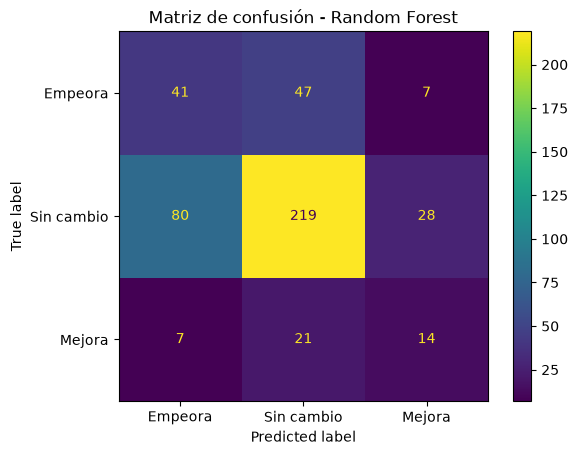

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_validation_change,
    rf_change_validation_pred,
    labels=[-1, 0, 1],
    display_labels=[
        "Empeora",
        "Sin cambio",
        "Mejora"
    ]
)

plt.title(
    "Matriz de confusión - Random Forest"
)

plt.show()

### Modelización del cambio de rating en dos etapas

La clasificación directa del cambio de rating en tres categorías —mejora, estabilidad y deterioro— muestra que las variables fundamentales contienen información predictiva sobre la evolución de las calificaciones, aunque la capacidad de discriminación entre las tres clases es limitada.

El Random Forest de tres categorías obtiene una balanced accuracy de 0,478 frente al valor de 0,333 del benchmark que predice sistemáticamente la ausencia de cambio. Por tanto, el modelo incorpora información adicional respecto a la simple persistencia del rating. Sin embargo, una parte importante de las mejoras y deterioros reales continúa siendo clasificada como ausencia de cambio.

Este resultado sugiere que la evolución del rating puede representarse de forma más adecuada mediante un proceso en dos etapas. En primer lugar, se analiza si durante el periodo siguiente se produce o no una modificación de la calificación. Posteriormente, condicionando el análisis a aquellas observaciones en las que efectivamente se produce un cambio, se estudia si dicho movimiento corresponde a una mejora o a un deterioro.

El enfoque permite separar dos cuestiones diferentes:

$$
\text{Etapa 1: ¿Se produce un cambio de rating?}
$$

$$
\text{Etapa 2: Si se produce un cambio, ¿es una mejora o un deterioro?}
$$

Esta estructura resulta especialmente apropiada dada la elevada persistencia observada en las calificaciones soberanas y permite estudiar de forma más específica qué variables fundamentales están asociadas tanto con la aparición de revisiones como con la dirección de dichas revisiones.

In [19]:
#etapa 1: cambio vs sin cambio
train_change["change_binary"] = (
    train_change["rating_change_t1"] != 0
).astype(int)

validation_change["change_binary"] = (
    validation_change["rating_change_t1"] != 0
).astype(int)

y_train_binary = (
    train_change["change_binary"]
)

y_validation_binary = (
    validation_change["change_binary"]
)

print("TRAIN")
print(
    y_train_binary
    .value_counts()
    .sort_index()
)

print("\nVALIDATION")
print(
    y_validation_binary
    .value_counts()
    .sort_index()
)

TRAIN
change_binary
0    1647
1     793
Name: count, dtype: int64

VALIDATION
change_binary
0    327
1    137
Name: count, dtype: int64


In [20]:
baseline_binary_pred = np.zeros(
    len(y_validation_binary),
    dtype=int
)

baseline_binary_results = {
    "Accuracy": accuracy_score(
        y_validation_binary,
        baseline_binary_pred
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation_binary,
        baseline_binary_pred
    ),
    "F1": f1_score(
        y_validation_binary,
        baseline_binary_pred
    )
}

display(
    pd.DataFrame(
        baseline_binary_results,
        index=["Siempre sin cambio"]
    ).round(3)
)

,Accuracy,Balanced Accuracy,F1
Siempre sin cambio,0.705,0.5,0.0


In [22]:
print(
    classification_report(
        y_validation_binary,
        baseline_binary_pred,
        target_names=[
            "Sin cambio",
            "Cambio"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Sin cambio       0.70      1.00      0.83       327
      Cambio       0.00      0.00      0.00       137

    accuracy                           0.70       464
   macro avg       0.35      0.50      0.41       464
weighted avg       0.50      0.70      0.58       464



In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

rf_binary_results = []

for n_estimators in [200, 500]:
    for max_depth in [10, 15, None]:
        for min_samples_leaf in [1, 5, 10]:
            for max_features in ["sqrt", 0.5]:

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_change,
                    y_train_binary
                )

                pred = model.predict(
                    X_validation_change
                )

                rf_binary_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "Accuracy": accuracy_score(
                        y_validation_binary,
                        pred
                    ),
                    "Balanced Accuracy": balanced_accuracy_score(
                        y_validation_binary,
                        pred
                    ),
                    "F1 Cambio": f1_score(
                        y_validation_binary,
                        pred
                    ),
                    "Recall Cambio": recall_score(
                        y_validation_binary,
                        pred
                    )
                })

In [24]:
rf_binary_results = pd.DataFrame(
    rf_binary_results
)

rf_binary_results = (
    rf_binary_results
    .sort_values(
        [
            "Balanced Accuracy",
            "F1 Cambio",
            "Recall Cambio"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_binary_results
    .head(10)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,Accuracy,Balanced Accuracy,F1 Cambio,Recall Cambio
0,500,15.0,10,sqrt,0.586,0.613,0.492,0.679
1,500,NaN,10,sqrt,0.588,0.613,0.491,0.672
2,500,15.0,1,sqrt,0.623,0.612,0.478,0.584
3,200,15.0,10,sqrt,0.580,0.611,0.491,0.686
4,500,NaN,1,sqrt,0.640,0.609,0.466,0.533
5,500,10.0,10,sqrt,0.560,0.607,0.493,0.723
6,200,15.0,5,sqrt,0.591,0.606,0.481,0.642
7,500,NaN,5,sqrt,0.599,0.603,0.475,0.613
8,200,10.0,10,sqrt,0.556,0.602,0.488,0.715
9,200,NaN,10,sqrt,0.575,0.601,0.480,0.664


el modelo consigue detectar aproximadamente 2 de cada 3 cambios reales de rating.

In [25]:
rf_binary_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_binary_model.fit(
    X_train_change,
    y_train_binary
)

rf_binary_validation_pred = (
    rf_binary_model.predict(
        X_validation_change
    )
)

print(
    classification_report(
        y_validation_binary,
        rf_binary_validation_pred,
        target_names=[
            "Sin cambio",
            "Cambio"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Sin cambio       0.80      0.55      0.65       327
      Cambio       0.39      0.68      0.49       137

    accuracy                           0.59       464
   macro avg       0.59      0.61      0.57       464
weighted avg       0.68      0.59      0.60       464



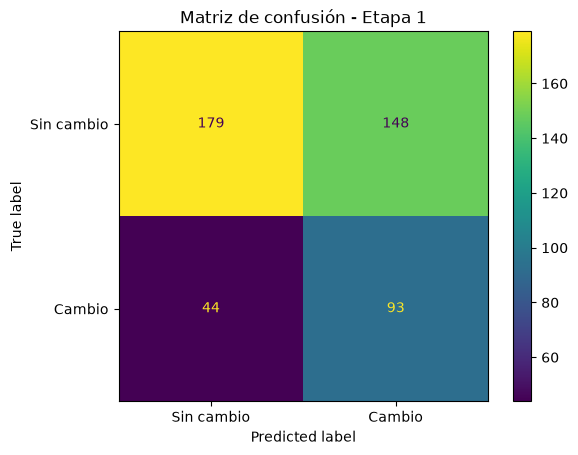

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_validation_binary,
    rf_binary_validation_pred,
    labels=[0, 1],
    display_labels=[
        "Sin cambio",
        "Cambio"
    ]
)

plt.title(
    "Matriz de confusión - Etapa 1"
)

plt.show()

### Etapa 2: dirección del cambio de rating

Una vez analizada la capacidad de las variables fundamentales para anticipar la existencia de una modificación del rating, la segunda etapa se centra exclusivamente en aquellas observaciones en las que se produce efectivamente un cambio de calificación.

El objetivo consiste en determinar si los fundamentales disponibles en el periodo t permiten anticipar la dirección de dicho movimiento:

$$
\text{Empeoramiento} = 0
$$

$$
\text{Mejora} = 1
$$

Esta segunda etapa elimina las observaciones en las que el rating permanece estable, permitiendo analizar específicamente los factores asociados con upgrades y downgrades.

La evaluación se realiza inicialmente de forma independiente sobre los cambios reales del conjunto de validación. Posteriormente, ambas etapas se combinarán para evaluar el funcionamiento completo del sistema de clasificación.

In [27]:
train_direction = train_change[
    train_change["rating_change_t1"] != 0
].copy()

validation_direction = validation_change[
    validation_change["rating_change_t1"] != 0
].copy()

In [28]:
train_direction["direction_target"] = (
    train_direction["rating_change_t1"] > 0
).astype(int)

validation_direction["direction_target"] = (
    validation_direction["rating_change_t1"] > 0
).astype(int)

print("TRAIN")
print(
    train_direction["direction_target"]
    .value_counts()
    .sort_index()
)

print("\nVALIDATION")
print(
    validation_direction["direction_target"]
    .value_counts()
    .sort_index()
)

TRAIN
direction_target
0    333
1    460
Name: count, dtype: int64

VALIDATION
direction_target
0    95
1    42
Name: count, dtype: int64


In [29]:
X_train_direction = (
    X_train_B
    .loc[train_direction.index]
    .copy()
)

X_validation_direction = (
    X_validation_B
    .loc[validation_direction.index]
    .copy()
)

y_train_direction = (
    train_direction["direction_target"]
)

y_validation_direction = (
    validation_direction["direction_target"]
)

print(
    "Train:",
    X_train_direction.shape
)

print(
    "Validation:",
    X_validation_direction.shape
)

Train: (793, 143)
Validation: (137, 143)


In [30]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report
)

baseline_direction_pred = np.zeros(
    len(y_validation_direction),
    dtype=int
)

baseline_direction_results = {
    "Accuracy": accuracy_score(
        y_validation_direction,
        baseline_direction_pred
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation_direction,
        baseline_direction_pred
    ),
    "F1 Macro": f1_score(
        y_validation_direction,
        baseline_direction_pred,
        average="macro"
    )
}

display(
    pd.DataFrame(
        baseline_direction_results,
        index=["Siempre empeora"]
    ).round(3)
)

print(
    classification_report(
        y_validation_direction,
        baseline_direction_pred,
        target_names=[
            "Empeora",
            "Mejora"
        ],
        zero_division=0
    )
)

,Accuracy,Balanced Accuracy,F1 Macro
Siempre empeora,0.693,0.5,0.409


              precision    recall  f1-score   support

     Empeora       0.69      1.00      0.82        95
      Mejora       0.00      0.00      0.00        42

    accuracy                           0.69       137
   macro avg       0.35      0.50      0.41       137
weighted avg       0.48      0.69      0.57       137



In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_direction_results = []

for n_estimators in [200, 500]:
    for max_depth in [10, 15, None]:
        for min_samples_leaf in [1, 5, 10]:
            for max_features in ["sqrt", 0.5]:

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_direction,
                    y_train_direction
                )

                pred = model.predict(
                    X_validation_direction
                )

                rf_direction_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "Accuracy": accuracy_score(
                        y_validation_direction,
                        pred
                    ),
                    "Balanced Accuracy": balanced_accuracy_score(
                        y_validation_direction,
                        pred
                    ),
                    "F1 Macro": f1_score(
                        y_validation_direction,
                        pred,
                        average="macro"
                    ),
                    "Recall Empeora": recall_score(
                        y_validation_direction,
                        pred,
                        pos_label=0
                    ),
                    "Recall Mejora": recall_score(
                        y_validation_direction,
                        pred,
                        pos_label=1
                    )
                })

In [32]:
rf_direction_results = pd.DataFrame(
    rf_direction_results
)

rf_direction_results = (
    rf_direction_results
    .sort_values(
        [
            "Balanced Accuracy",
            "F1 Macro"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_direction_results
    .head(10)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,Accuracy,Balanced Accuracy,F1 Macro,Recall Empeora,Recall Mejora
0,500,15.0,1,0.5,0.708,0.670,0.665,0.768,0.571
1,200,15.0,1,0.5,0.693,0.659,0.653,0.747,0.571
2,500,NaN,1,0.5,0.701,0.658,0.655,0.768,0.548
3,200,NaN,1,0.5,0.686,0.647,0.642,0.747,0.548
4,200,10.0,1,0.5,0.693,0.646,0.644,0.768,0.524
5,500,10.0,1,0.5,0.679,0.636,0.632,0.747,0.524
6,500,10.0,1,sqrt,0.686,0.621,0.623,0.789,0.452
7,200,10.0,1,sqrt,0.679,0.616,0.617,0.779,0.452
8,200,NaN,1,sqrt,0.679,0.616,0.617,0.779,0.452
9,500,15.0,1,sqrt,0.679,0.616,0.617,0.779,0.452


In [33]:
rf_direction_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=1,
    max_features=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_direction_model.fit(
    X_train_direction,
    y_train_direction
)

rf_direction_validation_pred = (
    rf_direction_model.predict(
        X_validation_direction
    )
)

print(
    classification_report(
        y_validation_direction,
        rf_direction_validation_pred,
        target_names=[
            "Empeora",
            "Mejora"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Empeora       0.80      0.77      0.78        95
      Mejora       0.52      0.57      0.55        42

    accuracy                           0.71       137
   macro avg       0.66      0.67      0.67       137
weighted avg       0.72      0.71      0.71       137



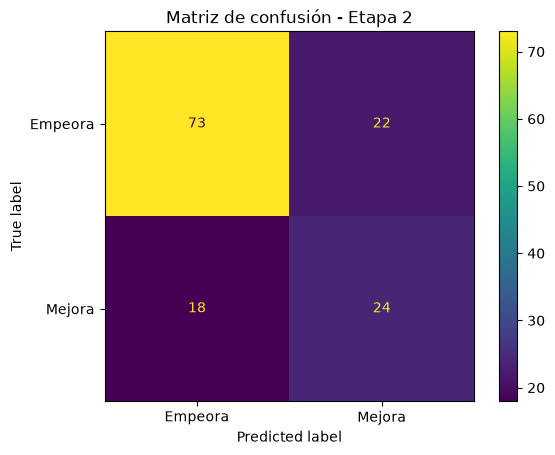

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_validation_direction,
    rf_direction_validation_pred,
    labels=[0, 1],
    display_labels=[
        "Empeora",
        "Mejora"
    ]
)

plt.title(
    "Matriz de confusión - Etapa 2"
)

plt.show()

### Resultados de la segunda etapa

La segunda etapa presenta una capacidad predictiva superior a la observada en la detección inicial de cambios. Considerando exclusivamente aquellas observaciones en las que efectivamente se produce una modificación del rating, el Random Forest alcanza una balanced accuracy de 0,670 y un F1 macro de 0,665.

El modelo identifica correctamente 73 de los 95 deterioros observados en validación, lo que supone un recall del 76,8 %. En el caso de las mejoras, clasifica correctamente 24 de las 42 observaciones, alcanzando un recall del 57,1 %.

Los resultados indican que, una vez producida una modificación de la calificación, las variables fundamentales contienen una señal relevante para anticipar la dirección del movimiento. La capacidad de discriminación resulta especialmente elevada para los deterioros, mientras que la identificación de mejoras presenta una mayor dificultad.

Esta diferencia puede estar relacionada, entre otros factores, con la distinta composición temporal de las clases, ya que durante el periodo de validación los deterioros presentan una frecuencia considerablemente superior a las mejoras.

En conjunto, estos resultados sugieren que el principal desafío predictivo reside en anticipar si se producirá una revisión del rating, mientras que, una vez condicionada la muestra a la existencia de un cambio, resulta más viable identificar su dirección.

In [35]:
# Predicción final inicial: sin cambio
two_stage_validation_pred = np.zeros(
    len(X_validation_change),
    dtype=int
)

# Observaciones para las que la etapa 1 predice cambio
predicted_change_mask = (
    rf_binary_validation_pred == 1
)

# Aplicar la etapa 2 solo a esos casos
direction_pred = rf_direction_model.predict(
    X_validation_change.loc[
        predicted_change_mask
    ]
)

# 0 en etapa 2 = empeora -> -1
# 1 en etapa 2 = mejora -> 1
two_stage_validation_pred[
    predicted_change_mask
] = np.where(
    direction_pred == 1,
    1,
    -1
)

In [36]:
print(
    classification_report(
        y_validation_change,
        two_stage_validation_pred,
        labels=[-1, 0, 1],
        target_names=[
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        zero_division=0
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_validation_change,
            two_stage_validation_pred
        ),
        3
    )
)

print(
    "F1 Macro:",
    round(
        f1_score(
            y_validation_change,
            two_stage_validation_pred,
            average="macro"
        ),
        3
    )
)

              precision    recall  f1-score   support

     Empeora       0.31      0.49      0.38        95
  Sin cambio       0.80      0.55      0.65       327
      Mejora       0.24      0.50      0.33        42

    accuracy                           0.53       464
   macro avg       0.45      0.51      0.45       464
weighted avg       0.65      0.53      0.57       464

Balanced Accuracy: 0.514
F1 Macro: 0.451


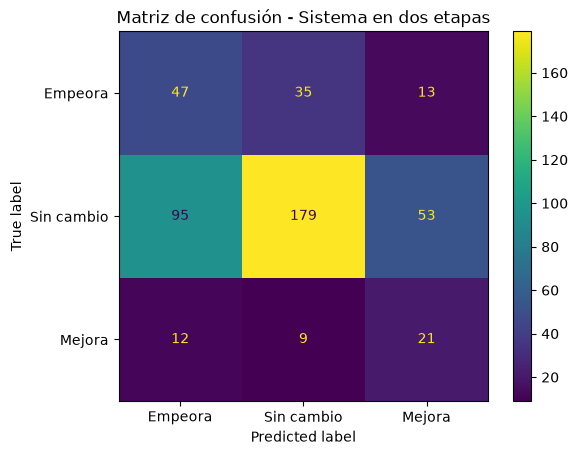

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_validation_change,
    two_stage_validation_pred,
    labels=[-1, 0, 1],
    display_labels=[
        "Empeora",
        "Sin cambio",
        "Mejora"
    ]
)

plt.title(
    "Matriz de confusión - Sistema en dos etapas"
)

plt.show()

Hemos detectado que la parte debil del modelo es la etapa 1, por lo que vamos a sustituir la erapa 1 por XGBoost.

### Mejora de la detección de cambios mediante XGBoost

Los resultados del sistema en dos etapas muestran que la principal dificultad se concentra en la primera fase, destinada a anticipar si el rating experimentará o no una modificación.

Mientras que el modelo encargado de determinar la dirección del cambio presenta una capacidad discriminante relativamente elevada, la detección inicial de revisiones resulta más limitada.

Por este motivo, se evalúa XGBoost como alternativa al Random Forest en la primera etapa. Este algoritmo de boosting permite modelizar relaciones no lineales e interacciones complejas entre las variables y resulta especialmente adecuado para problemas de clasificación con clases desequilibradas.

La segunda etapa permanece sin modificaciones, de forma que cualquier mejora obtenida pueda atribuirse exclusivamente a una mayor capacidad para anticipar la existencia de una revisión del rating.

In [39]:
scale_pos_weight = (
    (y_train_binary == 0).sum()
    / (y_train_binary == 1).sum()
)

print(
    "scale_pos_weight:",
    round(scale_pos_weight, 3)
)

scale_pos_weight: 2.077


In [40]:
from xgboost import XGBClassifier

xgb_binary_results = []

for n_estimators in [200, 500]:
    for max_depth in [3, 5]:
        for learning_rate in [0.03, 0.05, 0.1]:
            for min_child_weight in [1, 5]:

                model = XGBClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    learning_rate=learning_rate,
                    min_child_weight=min_child_weight,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=scale_pos_weight,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_change,
                    y_train_binary
                )

                pred = model.predict(
                    X_validation_change
                )

                xgb_binary_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "learning_rate": learning_rate,
                    "min_child_weight": min_child_weight,

                    "Accuracy": accuracy_score(
                        y_validation_binary,
                        pred
                    ),

                    "Balanced Accuracy":
                        balanced_accuracy_score(
                            y_validation_binary,
                            pred
                        ),

                    "F1 Cambio": f1_score(
                        y_validation_binary,
                        pred
                    ),

                    "Recall Cambio": recall_score(
                        y_validation_binary,
                        pred
                    )
                })
                

In [41]:
xgb_binary_results = pd.DataFrame(
    xgb_binary_results
)

xgb_binary_results = (
    xgb_binary_results
    .sort_values(
        [
            "Balanced Accuracy",
            "F1 Cambio"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_binary_results
    .head(10)
    .round(3)
)

,n_estimators,max_depth,learning_rate,min_child_weight,Accuracy,Balanced Accuracy,F1 Cambio,Recall Cambio
0,500,3,0.05,1,0.647,0.607,0.461,0.511
1,500,3,0.03,1,0.619,0.604,0.468,0.569
2,200,5,0.10,5,0.657,0.604,0.450,0.474
3,500,5,0.10,5,0.683,0.603,0.432,0.409
4,500,3,0.03,5,0.629,0.603,0.462,0.540
5,500,3,0.10,1,0.664,0.600,0.439,0.445
6,200,5,0.03,1,0.623,0.599,0.458,0.540
7,200,5,0.05,1,0.638,0.597,0.447,0.496
8,200,3,0.05,1,0.595,0.596,0.466,0.599
9,500,3,0.05,5,0.634,0.596,0.448,0.504


### Extra Trees como alternativa para la detección de cambios

Dado que XGBoost no mejora la capacidad de detección obtenida mediante Random Forest, se evalúa Extra Trees como alternativa para la primera etapa.

Este algoritmo mantiene la estructura basada en conjuntos de árboles, pero introduce una mayor aleatoriedad en la construcción de cada árbol. El objetivo es comprobar si esta diversificación adicional permite mejorar la identificación de las observaciones en las que se produce una modificación del rating.

La selección continúa realizándose exclusivamente sobre el conjunto de validación y utilizando como criterio principal la balanced accuracy.

In [42]:
from sklearn.ensemble import ExtraTreesClassifier

et_binary_results = []

for n_estimators in [200, 500]:
    for max_depth in [10, 15, 20, None]:
        for min_samples_leaf in [1, 5, 10]:
            for max_features in ["sqrt", 0.5, 1.0]:

                model = ExtraTreesClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_change,
                    y_train_binary
                )

                pred = model.predict(
                    X_validation_change
                )

                et_binary_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "Accuracy": accuracy_score(
                        y_validation_binary,
                        pred
                    ),
                    "Balanced Accuracy": balanced_accuracy_score(
                        y_validation_binary,
                        pred
                    ),
                    "F1 Cambio": f1_score(
                        y_validation_binary,
                        pred
                    ),
                    "Recall Cambio": recall_score(
                        y_validation_binary,
                        pred
                    )
                })

In [43]:
et_binary_results = pd.DataFrame(
    et_binary_results
)

et_binary_results = (
    et_binary_results
    .sort_values(
        [
            "Balanced Accuracy",
            "F1 Cambio"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    et_binary_results
    .head(10)
    .round(3)
)

,n_estimators,max_depth,min_samples_leaf,max_features,Accuracy,Balanced Accuracy,F1 Cambio,Recall Cambio
0,500,20.0,5,sqrt,0.634,0.632,0.503,0.628
1,200,NaN,10,sqrt,0.619,0.632,0.507,0.664
2,200,20.0,5,sqrt,0.631,0.630,0.501,0.628
3,500,15.0,5,sqrt,0.625,0.628,0.500,0.635
4,200,15.0,5,sqrt,0.621,0.627,0.500,0.642
5,200,NaN,5,sqrt,0.631,0.624,0.493,0.606
6,500,NaN,5,sqrt,0.627,0.623,0.493,0.613
7,200,20.0,10,sqrt,0.614,0.622,0.496,0.642
8,200,15.0,5,0.5,0.640,0.622,0.486,0.577
9,200,20.0,10,0.5,0.627,0.619,0.487,0.599


In [51]:
change_values = pd.concat([
    train_change["rating_change_t1"],
    validation_change["rating_change_t1"]
])

change_values = change_values[
    change_values != 0
]

print(change_values.describe().round(3))

print("\nCambios absolutos:")
print(
    change_values
    .abs()
    .describe()
    .round(3)
)

print("\nValores más frecuentes:")
display(
    change_values
    .value_counts()
    .head(20)
    .to_frame("Observaciones")
)

count    930.000
mean      -0.582
std        6.668
min      -44.167
25%       -3.333
50%        1.667
75%        3.333
max       20.000
Name: rating_change_t1, dtype: float64

Cambios absolutos:
count    930.000
mean       4.710
std        4.753
min        0.833
25%        1.667
50%        3.333
75%        5.000
max       44.167
Name: rating_change_t1, dtype: float64

Valores más frecuentes:


,Observaciones
rating_change_t1,
5.000000,120
2.500000,120
-2.500000,88
-5.000000,86
1.666667,31
1.666667,31
-10.000000,24
1.666667,24
1.666667,23


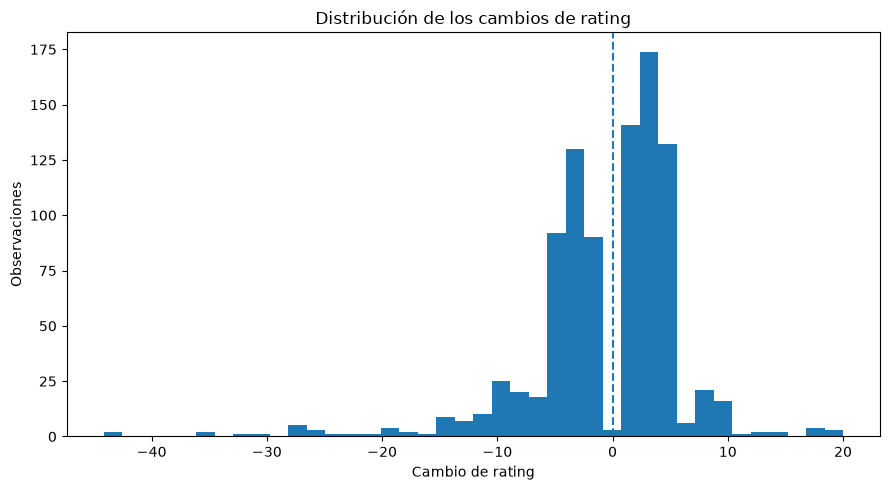

In [52]:
plt.figure(figsize=(9, 5))

plt.hist(
    change_values,
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Cambio de rating")
plt.ylabel("Observaciones")
plt.title("Distribución de los cambios de rating")

plt.tight_layout()
plt.show()

### Redefinición del cambio de rating

El análisis inicial considera como cambio cualquier variación de `rating_score_mean_t1` respecto a `rating_score_mean_t`. Sin embargo, al trabajar con una media de ratings procedentes de distintas agencias, pueden aparecer modificaciones pequeñas en la variable agregada aunque el movimiento crediticio subyacente sea limitado.

Por este motivo, se mantiene el análisis anterior de cualquier cambio de rating, pero se incorpora adicionalmente una definición más exigente de cambio material. Se considera mejora material cuando el rating aumenta al menos 5 puntos, deterioro material cuando disminuye al menos 5 puntos y ausencia de cambio material cuando la variación absoluta es inferior a 5 puntos:

$$
\Delta Rating \geq 5 \Rightarrow \text{Mejora material}
$$

$$
\Delta Rating \leq -5 \Rightarrow \text{Empeoramiento material}
$$

$$
|\Delta Rating| < 5 \Rightarrow \text{Sin cambio material}
$$

El umbral de 5 puntos no se establece con el objetivo de mejorar artificialmente el rendimiento del modelo, sino porque representa un escalón completo dentro de la escala numérica utilizada para transformar las calificaciones crediticias.

Este planteamiento permite distinguir entre pequeñas variaciones de la media de ratings y movimientos más relevantes de la calidad crediticia. De este modo, el análisis puede centrarse en una cuestión económicamente más significativa: determinar si las variables fundamentales permiten anticipar mejoras o deterioros materiales de la calificación soberana.

In [72]:
def material_change_distribution(data):

    sample = data[
        data["rating_change_t1"].notna()
    ].copy()

    sample["material_change"] = "Sin cambio material"

    sample.loc[
        sample["rating_change_t1"] >= 5,
        "material_change"
    ] = "Mejora"

    sample.loc[
        sample["rating_change_t1"] <= -5,
        "material_change"
    ] = "Empeora"

    counts = (
        sample["material_change"]
        .value_counts()
        .reindex(
            [
                "Mejora",
                "Sin cambio material",
                "Empeora"
            ],
            fill_value=0
        )
    )

    percentages = (
        counts
        / counts.sum()
        * 100
    )

    return pd.DataFrame({
        "Observaciones": counts,
        "Porcentaje": percentages
    })

In [73]:
print("TRAIN")
display(
    material_change_distribution(
        train
    ).round(2)
)

print("VALIDATION")
display(
    material_change_distribution(
        validation
    ).round(2)
)

TRAIN


,Observaciones,Porcentaje
material_change,,
Mejora,166,6.80
Sin cambio material,2117,86.76
Empeora,157,6.43


VALIDATION


,Observaciones,Porcentaje
material_change,,
Mejora,12,2.59
Sin cambio material,408,87.93
Empeora,44,9.48


### Viabilidad de la modelización de los cambios materiales

La aplicación de un umbral de cinco puntos permite diferenciar las variaciones marginales de los movimientos de mayor magnitud. Sin embargo, esta definición reduce considerablemente el número de observaciones pertenecientes a las clases de cambio.

En el conjunto de entrenamiento, únicamente el 6,80 % de las observaciones corresponden a mejoras materiales y el 6,43 % a deterioros materiales. Esta concentración aumenta en validación, donde el 87,93 % de las observaciones no presenta un cambio material, frente a únicamente 12 mejoras y 44 deterioros.

Aunque sería técnicamente posible estimar un modelo con estas categorías, el reducido número de observaciones, especialmente en la clase de mejora, limitaría considerablemente la robustez de la estimación y de su posterior evaluación. Las métricas obtenidas podrían resultar muy sensibles a un pequeño número de observaciones y dificultar la obtención de conclusiones generalizables.

Por este motivo, la definición de cambio material se mantiene como análisis descriptivo de la magnitud de las revisiones, pero no se utiliza como variable objetivo principal para la modelización. El análisis predictivo continúa utilizando cualquier variación del rating como evento de cambio, al disponer de una muestra considerablemente mayor.

A partir de esta definición, se explora si la incorporación de la evolución reciente de los fundamentales, además de sus niveles, permite mejorar la capacidad para anticipar las revisiones de rating.

### Incorporación de la dinámica de los fundamentales

Los modelos anteriores utilizan principalmente el nivel de las variables fundamentales observado en el periodo t. Sin embargo, para anticipar una modificación del rating puede resultar relevante no solo la situación actual del país, sino también la dirección en la que están evolucionando sus fundamentales.

Por ejemplo, dos países pueden presentar un nivel similar de deuda pública, pero mostrar trayectorias muy diferentes si en uno de ellos la deuda permanece estable y en el otro aumenta rápidamente. Esta información dinámica puede contener una señal adicional para anticipar futuras revisiones de la calificación crediticia.

Por este motivo, se incorporan variables que representan la variación anual de los fundamentales:

$$
\Delta X_t = X_t-X_{t-1}
$$

Estas variables se utilizan conjuntamente con los niveles originales, permitiendo que el modelo tenga en cuenta tanto la situación económica, fiscal, externa e institucional del país como su evolución reciente.

In [74]:
data_change = pd.concat(
    [
        train.copy(),
        validation.copy()
    ],
    axis=0
)

data_change = (
    data_change
    .sort_values(
        ["iso3", "year"]
    )
    .copy()
)

In [75]:
exclude_change_variables = [
    "year",
    "rating_score_mean_t",
    "rating_score_mean_t1",
    "rating_change_t1"
]

numeric_variables = (
    data_change
    .select_dtypes(
        include=np.number
    )
    .columns
)

numeric_fundamentals = [
    col
    for col in numeric_variables
    if col not in exclude_change_variables
]

print(
    "Variables numéricas:",
    len(numeric_fundamentals)
)

Variables numéricas: 96


In [76]:
delta_variables = []

for variable in numeric_fundamentals:

    new_variable = (
        "delta_" + variable
    )

    data_change[new_variable] = (
        data_change
        .groupby("iso3")[variable]
        .diff()
    )

    delta_variables.append(
        new_variable
    )

print(
    "Variables de cambio creadas:",
    len(delta_variables)
)

Variables de cambio creadas: 96


In [77]:
display(
    data_change[
        [
            "iso3",
            "year"
        ]
        + delta_variables[:10]
    ]
    .head(15)
)

,iso3,year,delta_exchange_rate_lcu_per_usd,delta_gdp_growth_pct,delta_gdp_per_capita_constant_2015_usd,delta_gdp_per_capita_ppp_constant_2021_intl_usd,delta_gdp_ppp_constant_2021_intl_usd,delta_gross_savings_pct_gdp,delta_inflation_cpi_pct,delta_investment_pct_gdp,delta_unemployment_pct,delta_fiscal_balance_pct_gdp
0,ABW,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,2010,0.000000,8.944285,-774.841639,-1037.141802,-9.741297e+07,-6.526295,4.213569,-1.359000,NaN,-0.855604
2,ABW,2011,0.000000,6.102694,663.836111,888.558572,1.167884e+08,-5.888767,2.238157,-0.866543,NaN,-2.942196
3,ABW,2012,0.000000,-4.410037,-648.320544,-867.790659,-3.729294e+07,6.990995,-3.688825,-3.894130,NaN,-2.525991
4,ABW,2013,0.000000,7.472261,1235.407456,1653.618818,2.280474e+08,1.447633,-2.999537,0.303353,NaN,2.907228
5,ABW,2014,0.000000,-5.005361,93.681790,125.395042,5.381897e+07,4.259868,2.793506,-0.714419,NaN,-1.410837
6,ABW,2015,0.000000,2.185380,684.397244,916.080080,1.382358e+08,3.807892,0.053323,-1.572574,NaN,5.983248
7,ABW,2016,0.000000,-2.377144,129.029650,172.708896,4.895266e+07,-0.092542,-1.405960,-0.963910,NaN,0.020308
8,ABW,2017,0.000000,2.259094,961.640628,1287.176170,1.402565e+08,-1.597532,-0.097086,-0.023786,NaN,-1.132043
9,ABW,2018,0.000000,-0.280959,870.318192,1164.939172,1.334821e+08,-2.533303,4.654323,1.850547,NaN,-0.054003


In [78]:
dynamic_candidates = [
    "gdp_ppp_constant_2021_intl_usd",
    "gdp_per_capita_constant_2015_usd",
    "gdp_per_capita_ppp_constant_2021_intl_usd",
    "inflation_cpi_pct",
    "unemployment_pct",
    "investment_pct_gdp",
    "gross_savings_pct_gdp",
    "government_debt_pct_gdp",
    "fiscal_balance_pct_gdp",
    "primary_balance_pct_gdp",
    "government_revenue_pct_gdp",
    "government_expenditure_pct_gdp",
    "net_interest_payments_pct_gdp",
    "current_account_balance_pct_gdp",
    "reserves_months_imports",
    "exports_pct_gdp",
    "imports_pct_gdp",
    "fdi_net_inflows_pct_gdp",
    "government_effectiveness_estimate",
    "regulatory_quality_estimate",
    "rule_of_law_estimate",
    "control_of_corruption_estimate",
    "political_stability_estimate",
    "voice_accountability_estimate",
    "electoral_democracy_index"
]

dynamic_variables = [
    col
    for col in dynamic_candidates
    if col in data_change.columns
]

print(
    "Variables dinámicas disponibles:",
    len(dynamic_variables)
)

print(dynamic_variables)

Variables dinámicas disponibles: 25
['gdp_ppp_constant_2021_intl_usd', 'gdp_per_capita_constant_2015_usd', 'gdp_per_capita_ppp_constant_2021_intl_usd', 'inflation_cpi_pct', 'unemployment_pct', 'investment_pct_gdp', 'gross_savings_pct_gdp', 'government_debt_pct_gdp', 'fiscal_balance_pct_gdp', 'primary_balance_pct_gdp', 'government_revenue_pct_gdp', 'government_expenditure_pct_gdp', 'net_interest_payments_pct_gdp', 'current_account_balance_pct_gdp', 'reserves_months_imports', 'exports_pct_gdp', 'imports_pct_gdp', 'fdi_net_inflows_pct_gdp', 'government_effectiveness_estimate', 'regulatory_quality_estimate', 'rule_of_law_estimate', 'control_of_corruption_estimate', 'political_stability_estimate', 'voice_accountability_estimate', 'electoral_democracy_index']


In [79]:
previous_year = (
    data_change
    .groupby("iso3")["year"]
    .shift(1)
)

consecutive_year = (
    data_change["year"]
    - previous_year
    == 1
)

selected_delta_variables = []

for variable in dynamic_variables:

    new_variable = (
        "delta_" + variable
    )

    data_change[new_variable] = (
        data_change
        .groupby("iso3")[variable]
        .diff()
    )

    data_change.loc[
        ~consecutive_year,
        new_variable
    ] = np.nan

    selected_delta_variables.append(
        new_variable
    )

print(
    "Deltas seleccionados:",
    len(selected_delta_variables)
)

Deltas seleccionados: 25


In [80]:
delta_summary = pd.DataFrame({
    "Variable": selected_delta_variables,
    "Missing_pct": [
        data_change[col]
        .isna()
        .mean()
        * 100
        for col in selected_delta_variables
    ]
})

display(
    delta_summary
    .sort_values("Missing_pct")
    .round(2)
)

,Variable,Missing_pct
1,delta_gdp_per_capita_constant_2015_usd,6.21
0,delta_gdp_ppp_constant_2021_intl_usd,8.34
2,delta_gdp_per_capita_ppp_constant_2021_intl_usd,8.34
10,delta_government_revenue_pct_gdp,8.67
8,delta_fiscal_balance_pct_gdp,8.74
11,delta_government_expenditure_pct_gdp,8.74
17,delta_fdi_net_inflows_pct_gdp,8.81
7,delta_government_debt_pct_gdp,9.31
4,delta_unemployment_pct,9.65
12,delta_net_interest_payments_pct_gdp,10.33


### Evaluación del valor predictivo de las variables dinámicas

Las variables de variación anual presentan niveles de información disponible suficientes para ser incorporadas al análisis. Ninguna de las variables seleccionadas supera el umbral del 20 % de valores ausentes.

Para evaluar de forma aislada la utilidad de esta nueva información, se mantiene inicialmente la misma configuración de Extra Trees seleccionada previamente para la detección de cambios de rating. De esta forma, la única modificación consiste en añadir las variaciones anuales de los fundamentales a las variables originales.

Este procedimiento permite determinar si la evolución reciente de los fundamentales aporta capacidad predictiva adicional respecto a utilizar exclusivamente sus niveles.

In [82]:
delta_train = (
    data_change
    .loc[
        train_change.index,
        selected_delta_variables
    ]
    .copy()
)

delta_validation = (
    data_change
    .loc[
        validation_change.index,
        selected_delta_variables
    ]
    .copy()
)

print(
    "Delta train:",
    delta_train.shape
)

print(
    "Delta validation:",
    delta_validation.shape
)

Delta train: (2440, 25)
Delta validation: (464, 25)


In [83]:
delta_medians = (
    delta_train
    .median()
)

delta_train_imputed = (
    delta_train
    .fillna(delta_medians)
)

delta_validation_imputed = (
    delta_validation
    .fillna(delta_medians)
)

In [84]:
delta_train_missing = (
    delta_train
    .isna()
    .astype(int)
)

delta_validation_missing = (
    delta_validation
    .isna()
    .astype(int)
)

delta_train_missing.columns = [
    "missingindicator_" + col
    for col in delta_train_missing.columns
]

delta_validation_missing.columns = (
    delta_train_missing.columns
)

In [85]:
X_train_change_dynamic = pd.concat(
    [
        X_train_change,
        delta_train_imputed,
        delta_train_missing
    ],
    axis=1
)

X_validation_change_dynamic = pd.concat(
    [
        X_validation_change,
        delta_validation_imputed,
        delta_validation_missing
    ],
    axis=1
)

print(
    "Train:",
    X_train_change_dynamic.shape
)

print(
    "Validation:",
    X_validation_change_dynamic.shape
)

print(
    "NaN train:",
    X_train_change_dynamic
    .isna()
    .sum()
    .sum()
)

print(
    "NaN validation:",
    X_validation_change_dynamic
    .isna()
    .sum()
    .sum()
)

Train: (2440, 193)
Validation: (464, 193)
NaN train: 0
NaN validation: 0


In [86]:
delta_medians = delta_train.median()

delta_train_imputed = (
    delta_train
    .fillna(delta_medians)
)

delta_validation_imputed = (
    delta_validation
    .fillna(delta_medians)
)

delta_train_missing = (
    delta_train
    .isna()
    .astype(int)
)

delta_validation_missing = (
    delta_validation
    .isna()
    .astype(int)
)

delta_train_missing.columns = [
    "missingindicator_" + col
    for col in delta_train_missing.columns
]

delta_validation_missing.columns = (
    delta_train_missing.columns
)

In [87]:
X_train_change_dynamic = pd.concat(
    [
        X_train_change,
        delta_train_imputed,
        delta_train_missing
    ],
    axis=1
)

X_validation_change_dynamic = pd.concat(
    [
        X_validation_change,
        delta_validation_imputed,
        delta_validation_missing
    ],
    axis=1
)

print(
    "Train:",
    X_train_change_dynamic.shape
)

print(
    "Validation:",
    X_validation_change_dynamic.shape
)

print(
    "NaN train:",
    X_train_change_dynamic.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_change_dynamic.isna().sum().sum()
)

Train: (2440, 193)
Validation: (464, 193)
NaN train: 0
NaN validation: 0


In [88]:
et_dynamic_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_dynamic_model.fit(
    X_train_change_dynamic,
    y_train_binary
)

et_dynamic_validation_pred = (
    et_dynamic_model.predict(
        X_validation_change_dynamic
    )
)

In [89]:
et_dynamic_results = {
    "Accuracy": accuracy_score(
        y_validation_binary,
        et_dynamic_validation_pred
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_validation_binary,
        et_dynamic_validation_pred
    ),
    "F1 Cambio": f1_score(
        y_validation_binary,
        et_dynamic_validation_pred
    ),
    "Recall Cambio": recall_score(
        y_validation_binary,
        et_dynamic_validation_pred
    )
}

display(
    pd.DataFrame(
        et_dynamic_results,
        index=["Extra Trees + dinámicas"]
    ).round(3)
)

,Accuracy,Balanced Accuracy,F1 Cambio,Recall Cambio
Extra Trees + dinámicas,0.616,0.622,0.494,0.635


In [90]:
print(
    classification_report(
        y_validation_binary,
        et_dynamic_validation_pred,
        target_names=[
            "Sin cambio",
            "Cambio"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Sin cambio       0.80      0.61      0.69       327
      Cambio       0.40      0.64      0.49       137

    accuracy                           0.62       464
   macro avg       0.60      0.62      0.59       464
weighted avg       0.68      0.62      0.63       464



### Resultado de la incorporación de variables dinámicas

La incorporación de las variaciones anuales de los fundamentales no mejora la capacidad predictiva de la primera etapa. El Extra Trees estimado únicamente con las variables originales alcanza una balanced accuracy de 0,632, un F1 de la clase cambio de 0,507 y un recall de 0,664.

Al añadir las variables dinámicas, la balanced accuracy se reduce hasta aproximadamente 0,625, mientras que el F1 de la clase cambio disminuye a 0,490 y su recall a 0,640.

Por tanto, la evolución anual de los fundamentales no aporta una mejora suficiente respecto a sus niveles originales. En consecuencia, estas variables adicionales se descartan y se mantiene la especificación original de Extra Trees para la detección de cambios.

In [93]:
from sklearn.ensemble import ExtraTreesClassifier

et_binary_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_binary_model.fit(
    X_train_change,
    y_train_binary
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when 

In [94]:
# Etapa 1
et_binary_validation_pred = (
    et_binary_model.predict(
        X_validation_change
    )
)

# Predicción final
final_validation_pred = np.zeros(
    len(X_validation_change),
    dtype=int
)

change_mask = (
    et_binary_validation_pred == 1
)

# Etapa 2
direction_pred = (
    rf_direction_model.predict(
        X_validation_change.loc[
            change_mask
        ]
    )
)

final_validation_pred[
    change_mask
] = np.where(
    direction_pred == 1,
    1,
    -1
)

print(
    classification_report(
        y_validation_change,
        final_validation_pred,
        labels=[-1, 0, 1],
        target_names=[
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        zero_division=0
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_validation_change,
            final_validation_pred
        ),
        3
    )
)

print(
    "F1 Macro:",
    round(
        f1_score(
            y_validation_change,
            final_validation_pred,
            average="macro"
        ),
        3
    )
)

              precision    recall  f1-score   support

     Empeora       0.31      0.45      0.37        95
  Sin cambio       0.81      0.60      0.69       327
      Mejora       0.26      0.52      0.35        42

    accuracy                           0.56       464
   macro avg       0.46      0.53      0.47       464
weighted avg       0.66      0.56      0.59       464

Balanced Accuracy: 0.525
F1 Macro: 0.469


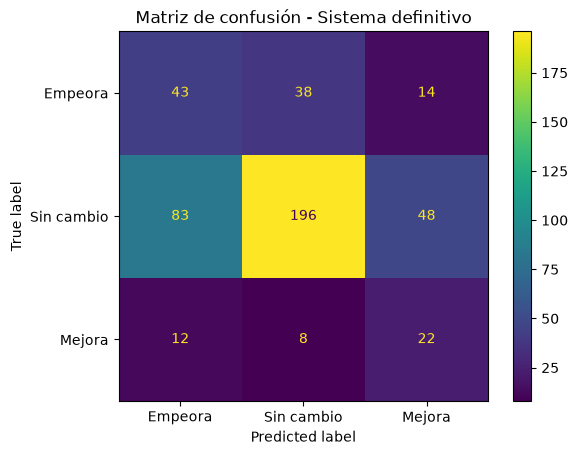

In [95]:
ConfusionMatrixDisplay.from_predictions(
    y_validation_change,
    final_validation_pred,
    labels=[-1, 0, 1],
    display_labels=[
        "Empeora",
        "Sin cambio",
        "Mejora"
    ]
)

plt.title(
    "Matriz de confusión - Sistema definitivo"
)

plt.show()

### Conclusión del análisis del cambio de rating

El análisis del cambio de rating presenta una dificultad considerablemente superior a la predicción del nivel futuro de la calificación.

La clasificación directa en tres categorías mostró una capacidad limitada para distinguir mejoras, estabilidad y deterioros. Por este motivo, se desarrolló posteriormente un sistema en dos etapas, separando primero la detección de una revisión del rating y, posteriormente, la dirección de dicha revisión.

La configuración finalmente seleccionada combina Extra Trees para identificar la existencia de un cambio y Random Forest para determinar si dicho movimiento corresponde a una mejora o a un deterioro.

Sobre el conjunto de validación, el sistema alcanza una balanced accuracy aproximada de 0,525 y un F1 macro de 0,469. El modelo identifica correctamente el 45,3 % de los deterioros, el 59,9 % de las observaciones sin cambio y el 52,4 % de las mejoras.

Estos resultados superan los obtenidos mediante la clasificación directa en tres categorías, aunque la mejora es moderada. Asimismo, la incorporación de variaciones anuales de los fundamentales no produjo una mejora adicional de la capacidad predictiva.

En consecuencia, los resultados indican que las variables fundamentales contienen cierta información para anticipar la dirección de las revisiones crediticias, pero la predicción del momento exacto en el que se produce un cambio continúa siendo especialmente difícil. Esta evidencia contrasta con la elevada capacidad predictiva obtenida para el nivel futuro del rating y confirma la fuerte persistencia temporal existente en las calificaciones soberanas.

Por tanto, el modelo de cambio se mantiene como análisis complementario del modelo principal de Random Forest, y no como sustituto del modelo utilizado para estimar el nivel futuro de rating.

In [96]:
# Etapa 1 en test
test_stage1_pred = (
    et_binary_model.predict(
        X_test_change
    )
)

# Predicción final
final_test_pred = np.zeros(
    len(X_test_change),
    dtype=int
)

change_mask_test = (
    test_stage1_pred == 1
)

# Etapa 2 solo cuando se predice cambio
direction_test_pred = (
    rf_direction_model.predict(
        X_test_change.loc[
            change_mask_test
        ]
    )
)

final_test_pred[
    change_mask_test
] = np.where(
    direction_test_pred == 1,
    1,
    -1
)

print(
    classification_report(
        y_test_change,
        final_test_pred,
        labels=[-1, 0, 1],
        target_names=[
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        zero_division=0
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_test_change,
            final_test_pred
        ),
        3
    )
)

print(
    "F1 Macro:",
    round(
        f1_score(
            y_test_change,
            final_test_pred,
            average="macro"
        ),
        3
    )
)

              precision    recall  f1-score   support

     Empeora       0.16      0.32      0.21        38
  Sin cambio       0.84      0.64      0.72       348
      Mejora       0.37      0.59      0.46        83

    accuracy                           0.60       469
   macro avg       0.46      0.51      0.46       469
weighted avg       0.70      0.60      0.63       469

Balanced Accuracy: 0.514
F1 Macro: 0.465


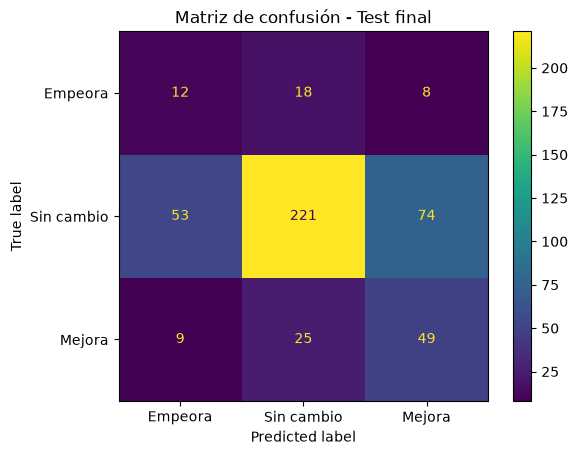

In [97]:
ConfusionMatrixDisplay.from_predictions(
    y_test_change,
    final_test_pred,
    labels=[-1, 0, 1],
    display_labels=[
        "Empeora",
        "Sin cambio",
        "Mejora"
    ]
)

plt.title(
    "Matriz de confusión - Test final"
)

plt.show()

### Evaluación final del modelo de cambio de rating

El sistema definitivo de clasificación del cambio de rating se evaluó sobre el conjunto de test, correspondiente al periodo temporal reservado para la evaluación fuera de muestra.

El modelo alcanza una balanced accuracy de 0,514 y un F1 macro de 0,465. Estos resultados son muy próximos a los obtenidos previamente en validación, donde se registraron valores de 0,525 y 0,469, respectivamente.

La estabilidad de ambas métricas indica que la capacidad predictiva observada durante la fase de validación se mantiene de forma similar en el periodo de test. No obstante, el rendimiento continúa siendo considerablemente inferior al obtenido en la predicción del nivel futuro del rating.

El comportamiento por clases muestra además diferencias relevantes. El modelo identifica correctamente el 63,5 % de las observaciones sin cambio y el 59,0 % de las mejoras, mientras que la detección de deterioros resulta más limitada, con un recall del 31,6 %.

En consecuencia, el análisis confirma que anticipar la aparición y dirección de una revisión crediticia constituye un problema considerablemente más complejo que estimar el nivel futuro de la calificación. Las variables fundamentales contienen cierta señal predictiva sobre los cambios de rating, pero esta capacidad resulta insuficiente para considerar el modelo de cambio como sustituto del modelo principal.

Por tanto, el sistema de clasificación se mantiene como análisis complementario destinado a estudiar la dinámica de las calificaciones, mientras que el Random Forest desarrollado para la estimación del nivel futuro del rating continúa constituyendo el modelo predictivo principal del trabajo.

In [98]:
CHANGE_MODEL_FILE = (
    MODEL_DATA_PATH
    / "notebook_6_change_models.joblib"
)

change_models = {
    "stage1_model": et_binary_model,
    "stage2_model": rf_direction_model,
    "stage1_model_name": "Extra Trees",
    "stage2_model_name": "Random Forest",
    "feature_names": list(X_train_change.columns),
    "validation_balanced_accuracy": 0.525,
    "validation_f1_macro": 0.469,
    "test_balanced_accuracy": 0.514,
    "test_f1_macro": 0.465
}

joblib.dump(
    change_models,
    CHANGE_MODEL_FILE
)

print(
    "Guardado en:",
    CHANGE_MODEL_FILE
)

Guardado en: data\model\notebook_6_change_models.joblib
